# S2 | Model: Three-Tier Text-Only Comparison

Compares how accuracy and behavior differ across three levels of vision-language integration
when models answer VQA questions **without seeing the image**:

| Tier | Description |
|---|---|
| **pretrained VLM** | Full VLM — vision encoder active, blank image fed in (`blind`) |
| **lm_decoder** | Same VLM weights, vision encoder bypassed — pure text path |
| **backbone** | Standalone LLM never co-trained with a vision encoder |

**Hypothesis:** If visual pre-training introduces language shortcuts, accuracy should be
`backbone < lm_decoder ≤ pretrained VLM` under blind conditions, and the instruction
effect (`blind → inst_blind`) should be largest for models most gated by language context.

**Conditions (blind only — original condition identical for text-only tiers):**
- `blind`: no instruction, blank/no image
- `inst_blind`: + instruction to imagine an image / use language knowledge

In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter, defaultdict

sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
sys.path.insert(0, '/home/david/Desktop/yuna/HPA')
from utils.constants import (
    ABSTAIN_TOKENS,
    BB_MODELS,
    CONDITIONS,
    CONTROL_TYPES,
    CT_LABELS,
    LM_MODELS,
    TIER_COLORS,
    TIER_ORDER,
    TIER_STYLE,
    TRIPLES,
    VLM_MODELS,
)
from utils.load_session import clean_answer
from utils.vqa import VQAAnswerMapper, vqa_accuracy

BASE    = Path('/home/david/Desktop/yuna/HPA/evaluation/logits')
VLM_DIR = BASE / 'pretrained'
LM_DIR  = BASE / 'lm_decoder/pretrained'
BB_DIR  = BASE / 'backbone/pretrained'
FIG_DIR = Path('/home/david/Desktop/yuna/HPA/analysis/figures')
FIG_DIR.mkdir(exist_ok=True)

mapper = VQAAnswerMapper()

def load(path):
    p = Path(path)
    if not p.exists():
        return None
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()]

def score(rows, ct='question'):
    if not rows:
        return np.nan
    return np.mean([
        vqa_accuracy(clean_answer(r['generated_answers'].get(ct, '')),
                     mapper.get_answers(r['question_id']))
        for r in rows
    ])

def abstain_rate(rows, ct='question'):
    if not rows:
        return np.nan
    return np.mean([
        any(token in clean_answer(r['generated_answers'].get(ct, '')).lower()
            for token in ABSTAIN_TOKENS)
        for r in rows
    ])

def inst_delta(blind_rows, inst_rows, ct='question'):
    if not blind_rows or not inst_rows:
        return np.nan
    return score(inst_rows, ct) - score(blind_rows, ct)

print('Dirs exist:', VLM_DIR.exists(), LM_DIR.exists(), BB_DIR.exists())
print(f'VLM models: {len(VLM_MODELS)},  VLM backbone decoder: {len(LM_MODELS)},  Backbone: {len(BB_MODELS)}')


Dirs exist: True True True
VLM models: 9,  VLM backbone decoder: 9,  Backbone: 7


## 1. Accuracy by Tier

In [2]:
# Build per-model accuracy table for all 3 tiers
rows = []
tier_map = [
    ('VLM',        VLM_DIR, VLM_MODELS),
    ('VLM backbone decoder', LM_DIR,  LM_MODELS),
    ('standalone LLM',   BB_DIR,  BB_MODELS),
]
for tier, tdir, models in tier_map:
    for model in models:
        for cond_suffix, cond_label, _ in CONDITIONS:
            r = load(tdir / model / f'vqa_1k{cond_suffix}.jsonl')
            if r is None: continue
            rows.append({
                'tier':      tier,
                'model':     model,
                'condition': cond_label,
                'acc':       score(r),
                'abstain':   abstain_rate(r),
                'n':         len(r),
            })

df = pd.DataFrame(rows)

# Tier-level summary
summary = df.groupby(['tier','condition'])['acc'].agg(['mean','std','count']).round(3)
print(summary.to_string())
print()
print(df[['tier','model','condition','acc','abstain']].to_string(index=False, float_format='%.3f'))

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
                        mean    std  count
tier       condition                      
Backbone   blind       0.159  0.149      5
           inst_blind  0.165  0.136      5
VLM backbone decoder blind       0.382  0.032      9
           inst_blind  0.386  0.025      9
VLM        blind       0.348  0.011      9
           inst_blind  0.352  0.013      9

      tier                    model  condition   acc  abstain
       VLM     Qwen3-VL-2B-Instruct      blind 0.357    0.038
       VLM     Qwen3-VL-2B-Instruct inst_blind 0.358    0.028
       VLM     Qwen3-VL-4B-Instruct      blind 0.345    0.120
       VLM     Qwen3-VL-4B-Instruct inst_blind 0.372    0.041
       VLM     Qwen3-VL-8B-Instruct      blind 0.342    0.105
       VLM     Qwen3-VL-8B-Instruct inst_blind 0.362    0.038
       VLM           InternVL3_5-1B      blind 0.352    0.000
       VLM    

In [ ]:
# Tier comparison figures are exported by:
#   conda run -n zero python figures/tier_analysis.py
# (or run_paper_figures.py)

## 6. Summary Table

In [8]:
# ── Per-model accuracy table + tier-level aggregates ─────────────────────────
print('=== Per-model ===')
print(df[['tier','model','condition','acc','abstain']]
      .sort_values(['tier','condition','acc'], ascending=[True,True,False])
      .to_string(index=False, float_format='%.3f'))

print('\n=== Tier × Condition averages ===')
agg = df.groupby(['tier','condition']).agg(
    n_models   = ('model','nunique'),
    mean_acc   = ('acc','mean'),
    std_acc    = ('acc','std'),
    mean_abst  = ('abstain','mean'),
).round(3)
print(agg.to_string())

=== Per-model ===
      tier                    model  condition   acc  abstain
  Backbone                 Qwen3-4B      blind 0.335    0.017
  Backbone                 Qwen3-8B      blind 0.297    0.112
  Backbone               Qwen3-1.7B      blind 0.110    0.116
  Backbone               Qwen3-0.6B      blind 0.053    0.000
  Backbone Mistral-7B-Instruct-v0.2      blind 0.001    0.442
  Backbone                 Qwen3-4B inst_blind 0.311    0.005
  Backbone                 Qwen3-8B inst_blind 0.279    0.038
  Backbone               Qwen3-1.7B inst_blind 0.182    0.051
  Backbone               Qwen3-0.6B inst_blind 0.050    0.000
  Backbone Mistral-7B-Instruct-v0.2 inst_blind 0.003    0.310
VLM backbone decoder llava-v1.6-mistral-7b-hf      blind 0.420    0.022
VLM backbone decoder          llava-1.5-7b-hf      blind 0.409    0.026
VLM backbone decoder     Qwen3-VL-4B-Instruct      blind 0.400    0.014
VLM backbone decoder  llava-v1.6-vicuna-7b-hf      blind 0.397    0.022
VLM backbone

## 7. VLM vs LM-Decoder: Answer Divergence and Logit Comparison

Do VLM and VLM backbone decoder give the same answers when run text-only (inst_blind)?
If answers differ, the vision encoder is shifting the language model's prior even without an image.

In [9]:
# ── Answer agreement between VLM and VLM backbone decoder (inst_blind) ─────────────────
# For each matched pair in TRIPLES, compute % identical answers across control types

agree_rows = []
for vlm_m, lm_m, bb_m, label in TRIPLES:
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl')
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl')
    if not vlm_rows or not lmd_rows: continue

    vlm_map = {r['question_id']: r for r in vlm_rows}
    lmd_map = {r['question_id']: r for r in lmd_rows}
    shared  = set(vlm_map) & set(lmd_map)

    for ct in CONTROL_TYPES:
        same, total = 0, 0
        for qid in shared:
            v = clean_answer(vlm_map[qid]['generated_answers'].get(ct, ''))
            l = clean_answer(lmd_map[qid]['generated_answers'].get(ct, ''))
            if v and l:
                same  += int(v == l)
                total += 1
        if total:
            agree_rows.append({'model': label, 'ct': ct,
                               'agreement': same / total, 'n': total})

agree_df = pd.DataFrame(agree_rows)
pivot    = agree_df.pivot(index='model', columns='ct', values='agreement')[CONTROL_TYPES]

print('Answer agreement rate — VLM vs VLM backbone decoder (inst_blind)')
print(pivot.round(3).to_string())
print()
print(f'Mean across all CTs: {agree_df["agreement"].mean():.3f}')


Answer agreement rate — VLM vs VLM backbone decoder (inst_blind)
ct          question  deictic_removed  object_removed  weaker_object  pronominalized
model                                                                               
Mistral-7B     0.555            0.563           0.488          0.538           0.401
Qwen3-4B       0.521            0.534           0.428          0.495           0.321
Qwen3-8B       0.553            0.566           0.475          0.541           0.409
Vicuna-7B      0.399            0.394           0.362          0.378           0.295

Mean across all CTs: 0.461


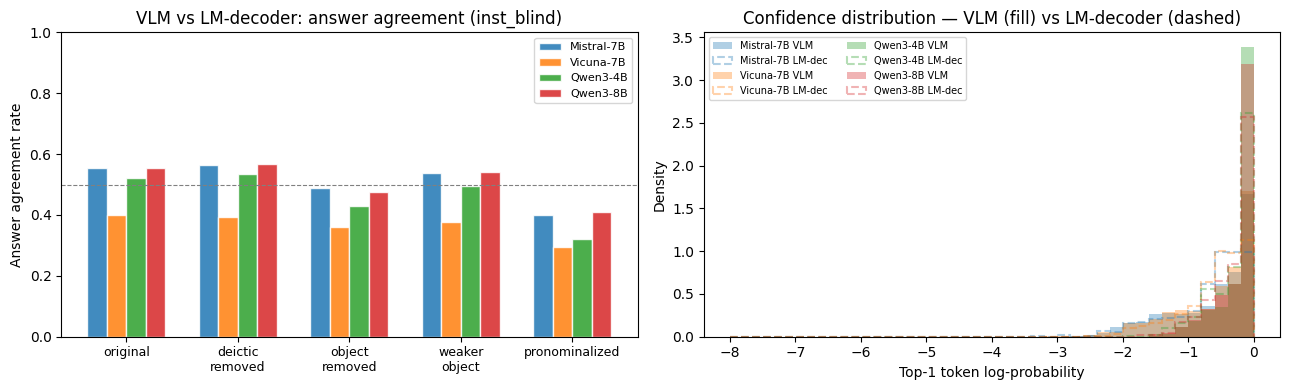

In [10]:
# ── Visualise agreement rate + top-logprob confidence ─────────────────────────
import math

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: agreement rate per control type × model pair
ax = axes[0]
x  = np.arange(len(CONTROL_TYPES))
w  = 0.7 / len(TRIPLES)
offsets = np.linspace(-(len(TRIPLES)-1)/2, (len(TRIPLES)-1)/2, len(TRIPLES)) * w
cmap = plt.get_cmap('tab10')

for i, (_, _, _, label) in enumerate(TRIPLES):
    sub = agree_df[agree_df['model'] == label].set_index('ct')
    vals = [sub.loc[ct, 'agreement'] if ct in sub.index else np.nan for ct in CONTROL_TYPES]
    ax.bar(x + offsets[i], vals, w, label=label, color=cmap(i), alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(CT_LABELS, fontsize=9)
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.set_ylabel('Answer agreement rate')
ax.set_title('VLM vs VLM backbone decoder: answer agreement (inst_blind)')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# Right: top-1 logprob distribution — VLM vs VLM backbone decoder (question CT only)
ax = axes[1]
for i, (vlm_m, lm_m, _, label) in enumerate(TRIPLES):
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl') or []
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl') or []

    def top1_lps(rows, ct='question'):
        lps = []
        for r in rows:
            gl = r.get('generated_logits', {}).get(ct, {}).get('content', [])
            if gl:
                lps.append(gl[0]['logprob'])
        return lps

    v_lps = top1_lps(vlm_rows)
    l_lps = top1_lps(lmd_rows)

    color = cmap(i)
    ax.hist(v_lps, bins=40, range=(-8, 0), density=True, alpha=0.35,
            color=color, label=f'{label} VLM')
    ax.hist(l_lps, bins=40, range=(-8, 0), density=True, alpha=0.35,
            color=color, histtype='step', lw=1.5, linestyle='--',
            label=f'{label} LM-dec')

ax.set_xlabel('Top-1 token log-probability'); ax.set_ylabel('Density')
ax.set_title('Confidence distribution — VLM (fill) vs VLM backbone decoder (dashed)')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()


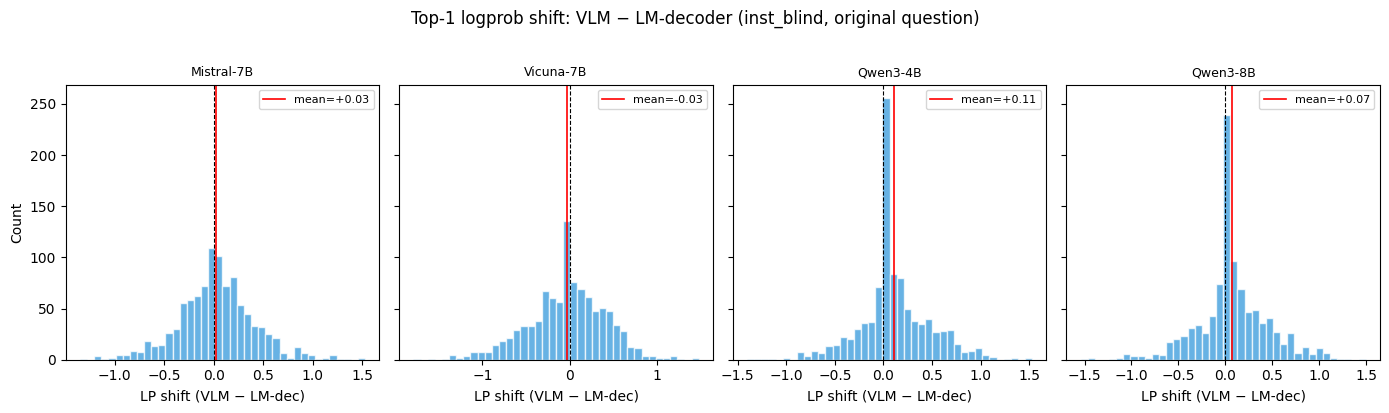

In [11]:
# ── Per-question logprob shift: VLM − VLM backbone decoder ──────────────────────────────
# For each question, how much does removing the vision encoder shift
# top-1 token confidence?  Positive = VLM more confident, Negative = LM-dec more confident

fig, axes = plt.subplots(1, len(TRIPLES), figsize=(14, 4), sharey=True)

for ax, (vlm_m, lm_m, _, label) in zip(axes, TRIPLES):
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl') or []
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl') or []
    vlm_map  = {r['question_id']: r for r in vlm_rows}
    lmd_map  = {r['question_id']: r for r in lmd_rows}

    shifts = []
    for qid in set(vlm_map) & set(lmd_map):
        v_gl = vlm_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        l_gl = lmd_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        if v_gl and l_gl:
            shifts.append(v_gl[0]['logprob'] - l_gl[0]['logprob'])

    ax.hist(shifts, bins=40, color='#3498db', alpha=0.75, edgecolor='white')
    ax.axvline(0,    color='black', lw=0.8, ls='--')
    ax.axvline(np.mean(shifts), color='red', lw=1.2,
               label=f'mean={np.mean(shifts):+.2f}')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('LP shift (VLM − LM-dec)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
plt.suptitle('Top-1 logprob shift: VLM − VLM backbone decoder (inst_blind, original question)', y=1.02)
plt.tight_layout(); plt.show()


In [12]:
# ── Examples: questions where VLM and VLM backbone decoder disagree most ────────────────
from utils.vqa import VQAAnswerMapper

_mapper = VQAAnswerMapper()
ctrl    = {int(json.loads(l)['question_id']): json.loads(l)
           for l in open(Path('/home/david/Desktop/yuna/HPA') /
                         'dataset/vqa/vqa1k_control.jsonl')}

print('=== Top disagreements (VLM vs VLM backbone decoder, inst_blind, question CT) ===\n')
for vlm_m, lm_m, _, label in TRIPLES[:2]:  # show first 2 pairs
    vlm_rows = load(VLM_DIR / vlm_m / 'vqa_1k_control_inst_blind.jsonl') or []
    lmd_rows = load(LM_DIR  / lm_m  / 'vqa_1k_control_inst_blind.jsonl') or []
    vlm_map  = {r['question_id']: r for r in vlm_rows}
    lmd_map  = {r['question_id']: r for r in lmd_rows}

    diffs = []
    for qid in set(vlm_map) & set(lmd_map):
        v_ans = clean_answer(vlm_map[qid]['generated_answers'].get('question',''))
        l_ans = clean_answer(lmd_map[qid]['generated_answers'].get('question',''))
        if v_ans.lower() == l_ans.lower(): continue
        gt    = _mapper.get_answers(qid)
        v_acc = vqa_accuracy(v_ans, gt)
        l_acc = vqa_accuracy(l_ans, gt)
        v_gl  = vlm_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        l_gl  = lmd_map[qid].get('generated_logits',{}).get('question',{}).get('content',[])
        v_lp  = v_gl[0]['logprob'] if v_gl else 0
        l_lp  = l_gl[0]['logprob'] if l_gl else 0
        diffs.append((abs(v_lp - l_lp), qid, v_ans, l_ans, gt[:3], v_acc, l_acc, v_lp, l_lp))

    diffs.sort(reverse=True)
    print(f'--- {label} (top 8 by LP shift) ---')
    for _, qid, v, l, gt, v_acc, l_acc, v_lp, l_lp in diffs[:8]:
        q = ctrl.get(qid, {}).get('question', '')[:55]
        print(f'  qid={qid}  "{q}"')
        print(f'    GT={gt}')
        print(f'    VLM:    {v!r:20}  acc={v_acc:.1f}  lp={v_lp:.2f}')
        print(f'    LM-dec: {l!r:20}  acc={l_acc:.1f}  lp={l_lp:.2f}')
    print()


=== Top disagreements (VLM vs VLM backbone decoder, inst_blind, question CT) ===

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
--- Mistral-7B (top 8 by LP shift) ---
  qid=16631021  "What does the sign say?"
    GT=['zone', 'zone', 'zone']
    VLM:    "The image you've provided is completely black, which makes it impossible to discern any text or signs. If you have a specific image in mind that you'd like to know about, please provide it so I can assist you."  acc=0.0  lp=-0.14
    LM-dec: 'No sign'             acc=0.0  lp=-1.66
  qid=562622004  "What does it say on the large billboard?"
    GT=['texas thank you', 'bud', 'bud']
    VLM:    'Nothing'             acc=0.0  lp=-0.34
    LM-dec: "I don't know what it says on the billboard."  acc=0.0  lp=-1.59
  qid=519471003  "What is the name on the banner?"
    GT=['ack hostingcom', 'jack hostingcom', 'ack hosting']
    VLM:    'No banner'           